In [1]:
import os
import re
import pyreadr
import numpy as np
import pandas as pd
from scipy import stats
from typing import List, Tuple
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold, train_test_split
import statsmodels.api as sm
import concurrent.futures
import matplotlib.pyplot as plt
from scipy.stats import chi2

In [2]:
# -----------------------------------------------------------------
# Set working directory
wkdir = r"C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/01transcriptome/00data/"
os.chdir(wkdir)

# -----------------------------------------------------------------
# File paths
#uthbCounts = r"00uthb_genecounts-08152025.csv.gz"
vabbCounts = r"00vabb_genecounts-08152025.csv.gz"

# Reading annotation
#uthbAnnot = r"00uthb_annotation-08152025.csv.gz"
vabbAnnot = r"00vabb_annotation-08152025.csv.gz"

# -----------------------------------------------------------------
# Read gzipped CSVs
#expr_uthb = pd.read_csv(uthbCounts, index_col=0, compression='gzip')
expr_vabb = pd.read_csv(vabbCounts, index_col=0, compression='gzip')
#annot_uthb = pd.read_csv(uthbAnnot, index_col=0, compression='gzip')
annot_vabb = pd.read_csv(vabbAnnot, index_col=0, compression='gzip')

# -----------------------------------------------------------------

In [3]:
# -----------------------------------------------------------------
# Loading metadata
# loading phenotype data
phenoPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/00phenotype/00vabb/00PhenoMeta_trainclock-07272025.csv"
phenoData = pd.read_csv(phenoPath)
# Create suffixes
suffixes = ["_9", "_24", "_25", "_11"]
# Replicate and modify pheno_data
phenoData = pd.concat([
    phenoData.assign(SampleID="Sample" + phenoData["SampleID"].astype(str) + suffix)
    for suffix in suffixes
], ignore_index=True)
phenoData.shape
# -----------------------------------------------------------------

(564, 6)

In [4]:
# Load cell types and SVAs
cells = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/05celltype-08042025/00vabb_cellprop_svas-08042025.csv")
cells = cells.rename(columns={'name': 'SampleID'})
cells.shape

(551, 17)

In [5]:
# Merge in sequence after conversion
merged_df_com = pd.merge(phenoData, cells, on='SampleID')
meta = merged_df_com
meta.shape

(546, 22)

In [6]:
# -----------------------------------------------------------------
# Subset meta to only required columns
meta = meta[['SampleID', 'Sex', 'PMI', 'RIN', 'AgeDeath', 'ast', 'end', 'mic', 'neu', 'oli', 'opc', 'W_1', 'W_2']]
# Columns not to scale
exclude_cols = ['SampleID', 'Sex', 'AgeDeath']

# Identify columns to scale
cols_to_scale = [col for col in meta.columns if col not in exclude_cols]

# Initialize scaler
scaler = StandardScaler(with_mean=True, with_std=True)

# Scale selected columns
meta_scaled = meta.copy()
meta_scaled[cols_to_scale] = scaler.fit_transform(meta_scaled[cols_to_scale])
# Set SampleID as index
meta_scaled = meta_scaled.set_index('SampleID')
meta_scaled.head()

,Sex,PMI,RIN,AgeDeath,ast,end,mic,neu,oli,opc,W_1,W_2
SampleID,,,,,,,,,,,,
Sample5205_9,Male,1.344314,1.002963,51,-0.985183,-0.718509,-0.410640,-0.266188,-0.664003,-0.952803,-0.108106,-0.192520
Sample5228_9,Female,0.646458,-1.095190,58,-0.633027,-0.839082,-0.563833,-0.297959,-0.658491,-0.931297,-0.037179,-0.167703
Sample5286_9,Female,0.879077,-1.394926,44,0.176086,0.233682,2.609995,0.242871,0.001352,0.322115,21.817682,2.574510
Sample5287_9,Male,1.189235,0.303579,40,-0.590237,-0.925822,-0.597451,-0.393386,-0.697382,-1.016107,-0.065587,-0.121521
Sample5323_9,Male,0.181221,-0.395805,35,-1.143411,-0.719600,-0.327777,-0.647711,-0.780717,-0.976483,-0.044045,-0.022014


In [7]:
# -----------------------------------------------------------------
# Function to clean sample names
def clean_sample_name(name):
    # Match "Sample<number><letters><number>" and replace with "Sample<number>_<number>"
    return re.sub(r"(Sample\d+)[A-Za-z]+(\d+)", r"\1_\2", name)

# Apply to a DataFrame
# Example: expr_uthb.columns = [clean_sample_name(c) for c in expr_uthb.columns]
expr_vabb.columns = [clean_sample_name(c) for c in expr_vabb.columns]
expr_vabb.head()
# -----------------------------------------------------------------

,Sample10027_24,Sample10027_9,Sample1093_24,Sample1093_9,Sample1124_24,Sample1124_9,Sample1185_24,Sample1185_9,Sample1201_24,Sample1201_9,...,Sample8050_11,Sample8050_25,Sample8082_11,Sample8082_25,Sample826_11,Sample826_25,Sample971_11,Sample971_25,Sample987_11,Sample987_25
ENSG00000284662,28,24,11,21,9,12,0,2,9,32,...,1,3,23,38,56,29,15,11,31,20
ENSG00000186827,10,16,9,5,2,9,9,17,3,45,...,11,6,33,7,91,26,8,10,73,29
ENSG00000186891,8,32,12,2,5,15,13,34,23,48,...,33,8,43,6,80,25,19,37,57,23
ENSG00000160072,529,1015,372,358,497,286,674,1161,504,1667,...,480,505,1633,714,4695,1521,573,959,3142,1684
ENSG00000041988,65,144,102,82,60,114,174,279,122,312,...,196,188,321,196,1103,375,108,259,729,373


In [8]:
# -----------------------------------------------------------------
# Define a function for the estimation FPKM of transcriptome data
def counts_to_fpkm(counts: pd.DataFrame, gene_lengths: pd.Series, lengths_in: str = "bp") -> pd.DataFrame:
    """
    Convert raw counts to FPKM.
    counts: genes x samples
    gene_lengths: length per gene (index aligned to counts)
    lengths_in: 'bp' or 'kb'
    """
    assert set(counts.index).issubset(set(gene_lengths.index)), "Gene lengths missing for some genes"  
    # Convert lengths to kilobases
    L = gene_lengths.loc[counts.index].astype(float)
    if lengths_in == "bp":
        L = L / 1e3
    elif lengths_in != "kb":
        raise ValueError("lengths_in must be 'bp' or 'kb'")
        
    # RPK: counts / length_kb
    rpk = counts.divide(L, axis=0)
    
    # FPKM: RPK / (total_mapped_reads_in_millions)
    per_sample_scaler = counts.sum(axis=0) / 1e6
    fpkm = rpk.divide(per_sample_scaler, axis=1)
    
    return fpkm

# -----------------------------------------------------------------
# Define a function for the estimation of gene lengths
def extract_gene_bounds(df: pd.DataFrame, start_col='Start', end_col='End'):
    """
    Extract first start and last end for genes where Start/End columns may contain multiple positions separated by ';'.
    
    Args:
        df: DataFrame with at least 'GeneID', start_col, end_col
        start_col: name of the start column
        end_col: name of the end column
        
    Returns:
        DataFrame with 'GeneID', 'Start', 'End', 'GeneLength'
    """
    starts = []
    ends = []
    for s, e in zip(df[start_col], df[end_col]):
        # Split by ',' and convert to int
        start_vals = [int(x) for x in str(s).split(';') if x.strip().isdigit()]
        end_vals   = [int(x) for x in str(e).split(';') if x.strip().isdigit()]
        if start_vals and end_vals:
            starts.append(min(start_vals))  # first start = smallest
            ends.append(max(end_vals))      # last end = largest
        else:
            starts.append(None)
            ends.append(None)
    
    result = pd.DataFrame({
        'GeneID': df['GeneID'],
        'Start': starts,
        'End': ends
    })
    
    # Compute gene length
    result['GeneLength'] = result['End'] - result['Start'] + 1
    return result

In [9]:
# -----------------------------------------------------------------
# Transforming to FPKM
gene_info_vabb = extract_gene_bounds(annot_vabb)
# Make Series: index = GeneID, values = GeneLength
gene_lengths = pd.Series(gene_info_vabb["GeneLength"].values, index=gene_info_vabb["GeneID"])
fpkm_matrix = counts_to_fpkm(expr_vabb, gene_lengths, lengths_in="bp")
fpkm_matrix.shape

(60605, 551)

In [10]:
# -----------------------------------------------------------------
# Filtering to FPKM
# To avoid the influence of low count genes on the analysis result, genes with more than 30% samples having count per million (CPM) less than one were filtered out
mfilter = (fpkm_matrix < 1).sum(axis=1) / fpkm_matrix.shape[1] <= 0.3
fpkm_matrix = fpkm_matrix.loc[mfilter]  # assign back
fpkm_matrix.shape

(9105, 551)

In [11]:
# -----------------------------------------------------------------
# Standardize by gene (rows)
scaler = StandardScaler(with_mean=True, with_std=True)
expr_z = pd.DataFrame(
    scaler.fit_transform(fpkm_matrix.T).T,  # transpose -> scale -> transpose back
    index=fpkm_matrix.index,  # keep gene names
    columns=fpkm_matrix.columns  # keep sample names
)
expr_z.head()

,Sample10027_24,Sample10027_9,Sample1093_24,Sample1093_9,Sample1124_24,Sample1124_9,Sample1185_24,Sample1185_9,Sample1201_24,Sample1201_9,...,Sample8050_11,Sample8050_25,Sample8082_11,Sample8082_25,Sample826_11,Sample826_25,Sample971_11,Sample971_25,Sample987_11,Sample987_25
ENSG00000160072,1.032523,1.711955,-0.085869,0.626116,0.142356,-1.534350,1.616278,1.263234,-0.076390,1.512895,...,-1.172818,-1.516864,0.582666,-1.194454,0.640007,0.532361,0.335098,-0.217445,0.644238,0.889257
ENSG00000225972,4.563008,2.811983,-0.264908,-0.292317,1.492488,1.045303,-0.526877,-0.460963,-0.016767,0.109340,...,-0.615557,-0.222504,-0.559921,-0.181519,-0.507210,-0.528148,-0.594211,-0.462490,-0.424670,-0.453273
ENSG00000224315,1.687359,1.046504,0.066807,-0.904123,-0.380758,-0.732082,-0.120664,0.096232,0.582366,0.223664,...,-0.987097,-0.856729,0.539175,0.351821,-0.847716,-0.410237,-1.351098,-0.682342,-0.145540,-0.445355
ENSG00000198744,1.343346,0.391138,0.306707,-0.097394,2.434571,0.206976,-0.331683,-0.358510,0.240591,0.187385,...,-0.827569,-0.682511,-0.790172,-0.369185,-0.779362,-0.781348,-0.841667,-0.805819,-0.807733,-0.750103
ENSG00000225630,0.955431,0.034720,-0.030795,-0.499710,2.005468,-0.202936,-1.023479,-0.962707,0.275962,0.120231,...,-0.572983,1.244179,-0.235424,1.823509,-0.246167,-0.595604,-0.130808,-0.240961,-0.328370,-0.490384


In [12]:
# -----------------------------------------------------------------
# Subsetting to only unique samples
# Example: columns in your expression matrix
columns = expr_z.columns  # expr is your genes x samples DataFrame
# Extract the prefix before the underscore
prefixes = [col.split('_')[0] for col in columns]
# Create a DataFrame to associate columns with prefixes
col_df = pd.DataFrame({'col': columns, 'prefix': prefixes})

# Set random seed for reproducibility
seed = 42
np.random.seed(seed)
# Sample one column per prefix
unique_cols = col_df.groupby('prefix')['col'].apply(lambda x: np.random.choice(x)).values
# Subset your expression matrix
expr_unique = expr_z[unique_cols]
# Check
print(expr_unique.shape)
print(expr_z.shape)

(9105, 143)
(9105, 551)


In [13]:
# -----------------------------------------------------------------
# Columns that were selected
unique_cols_set = set(unique_cols)
# Columns that were not selected
excluded_cols = [col for col in expr_z.columns if col not in unique_cols_set]
# Check
print("Number of selected columns:", len(unique_cols))
print("Number of excluded columns:", len(excluded_cols))
# Optional: print first 10 excluded columns
print("Excluded columns:", excluded_cols[:10])

Number of selected columns: 143
Number of excluded columns: 408
Excluded columns: ['Sample10027_24', 'Sample10027_9', 'Sample1093_24', 'Sample1093_9', 'Sample1124_9', 'Sample1185_24', 'Sample1185_9', 'Sample1201_24', 'Sample1201_9', 'Sample1221_24']


In [14]:
# -----------------------------------------------------------------
# Saving Samples
# -----------------------------------------------------------------
# Save selected samples
pd.Series(unique_cols, name="Training_Samples").to_csv(
    "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00elasticnet-08152025/00training_samples-08162025.csv", index=False
)
# Save excluded samples
pd.Series(excluded_cols, name="Testing_Samples").to_csv(
    "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00elasticnet-08152025/00testing_samples-08162025.csv", index=False
)
print("Saved selected and excluded sample lists.")

Saved selected and excluded sample lists.


In [15]:
# ------------------------------
# Align samples
common_samples = expr_unique.columns.intersection(meta_scaled.index)
expr_unique = expr_unique[common_samples]
meta_scaled2 = meta_scaled.loc[common_samples]
print(expr_unique.shape)
print(meta_scaled2.shape)

(9105, 141)
(141, 12)


In [16]:
# ------------------------------
# Differential expression with covariate adjustment
# ------------------------------
#    - Encode categorical variables (e.g., Sex) using pd.get_dummies
meta_numeric = pd.get_dummies(meta_scaled2, columns=['Sex'], drop_first=True)

# Add intercept
X = sm.add_constant(meta_numeric)
Xt = X.values# One-hot encode categorical variables (e.g., Sex) first
meta_numeric = pd.get_dummies(meta_scaled, columns=['Sex'], drop_first=True)

# Add intercept
X = sm.add_constant(meta_numeric)

# Align samples
common_samples = expr_unique.columns.intersection(X.index)
expr_unique = expr_unique[common_samples]
X = X.loc[common_samples]

# Convert to float
Xt = X.values.astype(float)

# Find age column index
age_idx = list(X.columns).index('AgeDeath')

# Function to run OLS for one gene
def fit_gene_ols(gene_id):
    y = expr_unique.loc[gene_id].values
    model = sm.OLS(y, Xt)
    res = model.fit()
    coef_age = res.params[age_idx]
    se_age = res.bse[age_idx]
    t_age = res.tvalues[age_idx]
    p_age = res.pvalues[age_idx]
    return gene_id, coef_age, se_age, t_age, p_age

# Run in parallel
results = []
with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:  # adjust number of threads
    futures = [executor.submit(fit_gene_ols, g) for g in expr_z.index]
    for fut in concurrent.futures.as_completed(futures):
        results.append(fut.result())

# Compile results
deg = pd.DataFrame(results, columns=['gene_id', 'beta_age', 'se_age', 't_age', 'p_age']).set_index('gene_id')

# Benjamini–Hochberg FDR
deg = deg.sort_values('p_age')
m = len(deg)
ranks = np.arange(1, m + 1)
deg['fdr_age'] = (deg['p_age'] * m / ranks).clip(upper=1.0)
deg = deg.sort_index()
# Inspect
deg.head()

,beta_age,se_age,t_age,p_age,fdr_age
gene_id,,,,,
ENSG00000001461,-0.002115,0.004433,-0.477148,0.634070,0.858214
ENSG00000001561,-0.001787,0.006721,-0.265904,0.790741,0.924461
ENSG00000002330,-0.004544,0.006232,-0.729180,0.467224,0.753200
ENSG00000002834,-0.015238,0.005862,-2.599431,0.010434,0.129790
ENSG00000003056,0.010060,0.004955,2.030318,0.044396,0.253752


In [17]:
# Saving Differentially expressed genes
deg.to_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00elasticnet-08152025/00deg_age-08152025.csv", index=True)

Genomic inflation factor λ = 2.169494938001443


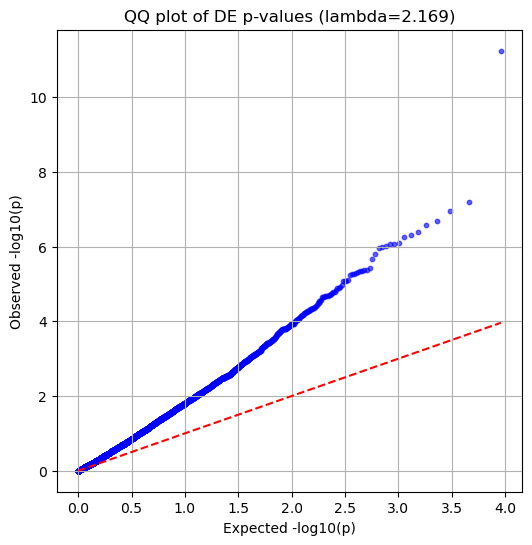

In [18]:
# ------------------------------
# Making a QQplot
# ------------------------------
# P-values
pvals = deg['p_age'].dropna().values

# Convert p-values to chi-squared statistics (df=1)
chisq = chi2.isf(pvals, df=1)

# Estimate lambda
lambda_gc = np.median(chisq) / chi2.ppf(0.5, df=1)
print("Genomic inflation factor λ =", lambda_gc)

# QQ plot
observed = -np.log10(np.sort(pvals))
expected = -np.log10(np.linspace(1/len(pvals), 1, len(pvals)))

plt.figure(figsize=(6,6))
plt.scatter(expected, observed, s=10, color='blue', alpha=0.6)
plt.plot([0, max(expected)], [0, max(expected)], color='red', linestyle='--')  # y=x line
plt.xlabel('Expected -log10(p)')
plt.ylabel('Observed -log10(p)')
plt.title(f'QQ plot of DE p-values (lambda={lambda_gc:.3f})')
plt.grid(True)
plt.show()

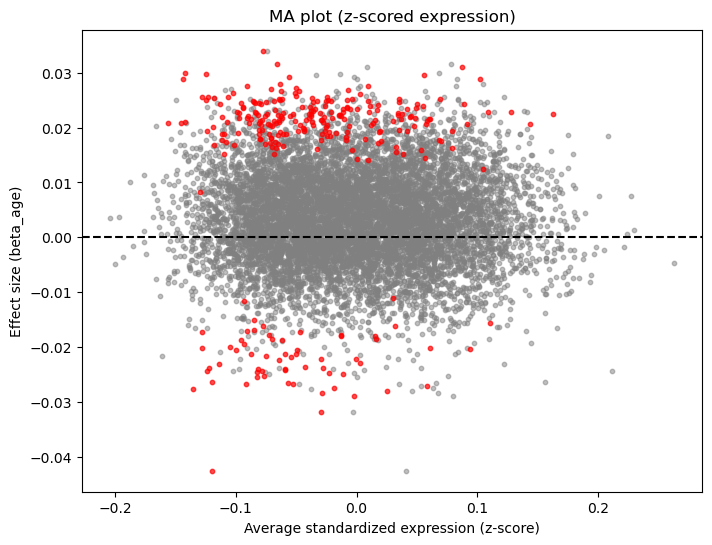

In [19]:
# Calculate average standardized expression per gene
mean_z_expr = expr_unique.mean(axis=1)  # expr_z is z-scored genes x samples
# M = effect size
M = deg['beta_age']

# Plotting
plt.figure(figsize=(8,6))
plt.scatter(mean_z_expr, M, s=10, alpha=0.5, color='gray')

# Highlight significant genes
sig_genes = deg['fdr_age'] < 0.05
plt.scatter(mean_z_expr[sig_genes], M[sig_genes], s=10, alpha=0.7, color='red')

plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Average standardized expression (z-score)')
plt.ylabel('Effect size (beta_age)')
plt.title('MA plot (z-scored expression)')
plt.show()

In [20]:
# ------------------------------
# Selecting gene features
# ------------------------------
# Feature selection
# Parameters
fdr_alpha = 0.05   # FDR threshold

# Feature selection
fdr_mask = deg['fdr_age'] <= fdr_alpha
sig = deg[fdr_mask]
# Take top N by absolute beta_age
selected_genes = sig.index.tolist()
print(len(selected_genes))

279


In [21]:
# ------------------------------
# Model training
# ------------------------------
def train_elastic_net(
    z_expr: pd.DataFrame,
    y_age: pd.Series,
    selected_genes: List[str],
    n_splits: int = 5,
    random_state: int = 42,
    l1_ratios: Tuple[float, ...] = (0.1, 0.3, 0.5, 0.7, 0.9)
) -> Tuple[ElasticNetCV, dict]:
    """Fit ElasticNetCV on selected genes, return model and CV metrics."""
    
    # Align genes and transpose so samples are rows
    X = z_expr.loc[selected_genes].T
    y = y_age.loc[X.index]  # ensure samples match
    
    # Initialize CV
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    # Fit ElasticNetCV on all data
    model = ElasticNetCV(l1_ratio=l1_ratios, alphas=None, cv=cv, max_iter=20000)
    model.fit(X, y)
    
    # Out-of-fold predictions
    preds = np.zeros(len(y), dtype=float)
    for train_idx, test_idx in cv.split(X):
        Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
        ytr = y.iloc[train_idx]
        m = ElasticNetCV(l1_ratio=l1_ratios, alphas=None, cv=cv, max_iter=20000)
        m.fit(Xtr, ytr)
        preds[test_idx] = m.predict(Xte)
    
    # CV metrics
    r2 = r2_score(y, preds)
    mae = mean_absolute_error(y, preds)
    metrics = {"cv_r2": float(r2), "cv_mae": float(mae)}
    
    return model, metrics

In [22]:
# ------------------------------
# Model training
# ------------------------------
# Extract age
# Extract age as a Series
y_age = meta_scaled2['AgeDeath']  # replace 'Age' with the exact column name if different
y_age = pd.Series(y_age, name='AgeDeath')  # ensures it's a Series with a name

# Train model
model, metrics = train_elastic_net(
    z_expr=expr_unique,
    y_age=y_age,
    selected_genes=selected_genes,
    n_splits=5,
    random_state=42,
    l1_ratios=(0.1, 0.3, 0.5, 0.7, 0.9)
)

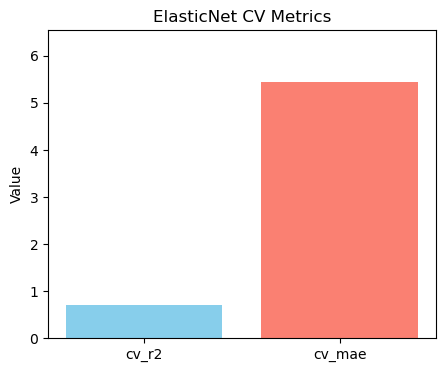

In [23]:
# ------------------------------
# Plotting metrics
# ------------------------------
# Convert to lists for plotting
names = list(metrics.keys())
values = list(metrics.values())

# Create bar plot
plt.figure(figsize=(5, 4))
plt.bar(names, values, color=['skyblue', 'salmon'])
plt.ylabel("Value")
plt.title("ElasticNet CV Metrics")
plt.ylim(0, max(values)*1.2)  # add some space on top
plt.show()

In [24]:
# ------------------------------
# Saving Coefficients
# ------------------------------
# Coefficients as Series (gene names as index)
coef_series = pd.Series(model.coef_, index=selected_genes, name='coef')
coef_series.to_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00elasticnet-08152025/01elastic_net_coefficients-08152025.csv", header=True)

# Optional only non-zero coeficients
nonzero_coef = coef_series[coef_series != 0]
nonzero_coef.to_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00elasticnet-08152025/02elastic_net_nonzero_coefficients-08152025.csv", header=True)

# Print intercept
print("Intercept:", model.intercept_)

# Save intercept
pd.Series({"intercept": model.intercept_}).to_csv(
    "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00elasticnet-08152025/03elastic_net_intercept-08152025.csv"
)

Intercept: 45.816125843226956


In [25]:
# ------------------------------
# Predicting with Coefficients
# ------------------------------
# Expression matrix for excluded samples
expr_excluded = expr_z[excluded_cols]
# Make sure the same genes are used (selected_genes)
X_excluded = expr_excluded.loc[selected_genes]

# Load coefficients
df_coef = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00elasticnet-08152025/02elastic_net_nonzero_coefficients-08152025.csv", index_col=0)
# Convert the single-column DataFrame to a Series
coef_series = pd.Series(df_coef['coef'].values, index=df_coef.index, name='coef')
# Ensure it's a Series
coef_series = pd.Series(coef_series, name='coef')
# Subset new expression matrix to selected genes
X_new = X_excluded.loc[coef_series.index].T  # samples x genes

# Load the intercept CSV
df_intercept = pd.read_csv(
    "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00elasticnet-08152025/03elastic_net_intercept-08152025.csv",
    index_col=0
)

# Extract the value
intercept = df_intercept.loc["intercept"].values[0]

# Dot product to get predicted age
predicted_age = X_new.dot(coef_series) + intercept

# Convert to Series
predicted_age = pd.Series(predicted_age, index=X_new.index, name='Predicted_Age')

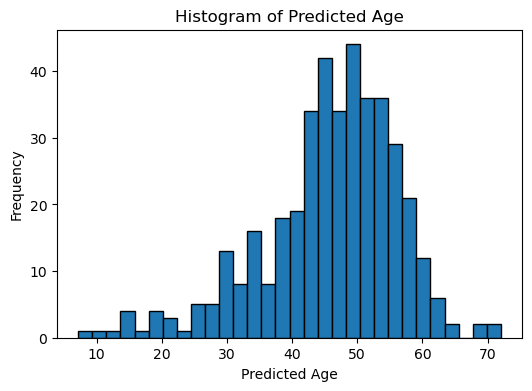

In [26]:
# If predicted_age is a Pandas Series
plt.figure(figsize=(6,4))
plt.hist(predicted_age, bins=30, edgecolor="black")
plt.xlabel("Predicted Age")
plt.ylabel("Frequency")
plt.title("Histogram of Predicted Age")
plt.show()

Correlation between predicted and AgeDeath: 0.884


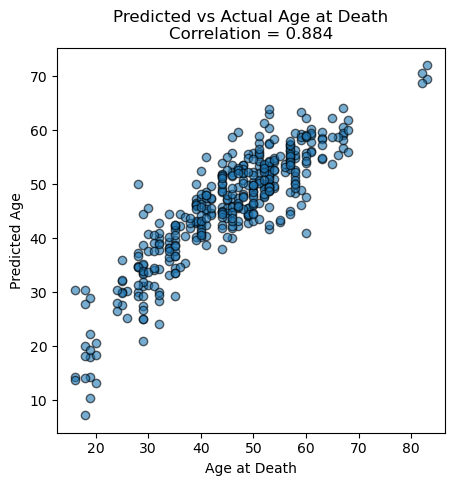

In [27]:
# Now align with predicted_age
common_ids = predicted_age.index.intersection(meta_scaled.index)
ages = meta_scaled.loc[common_ids, "AgeDeath"]
pred = predicted_age.loc[common_ids]

# Correlation
corr = pred.corr(ages)
print(f"Correlation between predicted and AgeDeath: {corr:.3f}")

# Scatter plot
plt.figure(figsize=(5,5))
plt.scatter(ages, pred, alpha=0.6, edgecolor="k")
plt.xlabel("Age at Death")
plt.ylabel("Predicted Age")
plt.title(f"Predicted vs Actual Age at Death\nCorrelation = {corr:.3f}")
plt.show()

In [28]:
# Saving predictions
# Create a DataFrame with sample IDs and predicted age
df_pred = pd.DataFrame({
    "SampleID": predicted_age.index,
    "Predicted_Age": predicted_age.values
})
# Save to CSV
df_pred.to_csv(
    "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00elasticnet-08152025/04vabb_prediction-08152025.csv", 
    index=False
)

print("Predicted ages saved to 'predicted_age_samples.csv'.")

Predicted ages saved to 'predicted_age_samples.csv'.
